<a href="https://colab.research.google.com/github/8009678200/ML.github.io/blob/main/sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis Project

Sentiment analysis, also known as opinion mining, is a natural language processing (NLP) technique used to determine whether data is positive, negative, or neutral. It's often used on textual data to help businesses monitor brand and product sentiment in customer feedback, and understand customer needs.

In this project, we'll perform sentiment analysis on a sample dataset. Here are the steps we will follow:
1. **Setup**: Install necessary libraries and load a dataset.
2. **Data Exploration**: Understand the structure and content of the dataset.
3. **Preprocessing**: Clean and prepare the text data for analysis.
4. **Sentiment Analysis**: Apply a pre-trained model or develop a custom model to classify sentiment.
5. **Visualization**: Visualize the sentiment distribution and key insights.

## 1. Setup

In [ ]:
# Install necessary libraries
!pip install pandas nltk textblob matplotlib seaborn

In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from textblob import TextBlob
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK data for sentiment analysis (VADER lexicon)
try:
    nltk.data.find('sentiment/vader_lexicon.zip')
except LookupError:
    nltk.download('vader_lexicon')

print("Libraries installed and NLTK data downloaded.")

Libraries installed and NLTK data downloaded.


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


## 2. Data Exploration

For this project, since no specific dataset was provided, we'll create a small sample dataset of product reviews to demonstrate the sentiment analysis process. In a real-world scenario, you would load your data from a CSV, JSON, or database.

In [ ]:
# Create a sample dataset
data = {
    'review_id': [1, 2, 3, 4, 5, 6, 7, 8],
    'text': [
        "This product is absolutely amazing! I love it.",
        "It's okay, not great, not terrible.",
        "Terrible quality, completely disappointed.",
        "Works as expected, very satisfied.",
        "Could be better, a bit flimsy.",
        "Best purchase ever! Highly recommend.",
        "Waste of money, would not buy again.",
        "Indifferent about this, it just exists."
    ]
}
df = pd.DataFrame(data)

print("Sample DataFrame created:")
print(df.head())
print(f"\nDataset shape: {df.shape}")
print("\nChecking for missing values:")
print(df.isnull().sum())

Sample DataFrame created:
   review_id                                            text
0          1  This product is absolutely amazing! I love it.
1          2             It's okay, not great, not terrible.
2          3      Terrible quality, completely disappointed.
3          4              Works as expected, very satisfied.
4          5                  Could be better, a bit flimsy.

Dataset shape: (8, 2)

Checking for missing values:
review_id    0
text         0
dtype: int64


## 3. Preprocessing

Text preprocessing is a critical step in NLP to clean and normalize text data, making it suitable for analysis. Common steps include converting text to lowercase, removing punctuation, numbers, and stop words. For this example, we'll focus on converting to lowercase and removing punctuation.

In [ ]:
import re

def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation and numbers
    return text

df['cleaned_text'] = df['text'].apply(preprocess_text)

print("Text preprocessing complete. Here's a sample of the cleaned text:")
print(df[['text', 'cleaned_text']].head())

Text preprocessing complete. Here's a sample of the cleaned text:
                                             text  \
0  This product is absolutely amazing! I love it.   
1             It's okay, not great, not terrible.   
2      Terrible quality, completely disappointed.   
3              Works as expected, very satisfied.   
4                  Could be better, a bit flimsy.   

                                   cleaned_text  
0  this product is absolutely amazing i love it  
1               its okay not great not terrible  
2      terrible quality completely disappointed  
3              works as expected very satisfied  
4                  could be better a bit flimsy  


## 4. Sentiment Analysis

Now that our text is cleaned, we can perform sentiment analysis. We'll use two popular libraries:

1.  **TextBlob**: Provides a simple API for common NLP tasks, including sentiment analysis (polarity and subjectivity).
2.  **NLTK's VADER (Valence Aware Dictionary and sEntiment Reasoner)**: A lexicon and rule-based sentiment analysis tool specifically attuned to sentiments expressed in social media, and works well on texts from other domains too. It provides a polarity score (negative, neutral, positive, and compound).

In [ ]:
# 1. Sentiment Analysis with TextBlob
def get_textblob_sentiment(text):
    analysis = TextBlob(text)
    # Polarity ranges from -1.0 (negative) to 1.0 (positive)
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df['textblob_sentiment'] = df['cleaned_text'].apply(get_textblob_sentiment)

print("TextBlob Sentiment Analysis Complete. Sample:")
print(df[['text', 'cleaned_text', 'textblob_sentiment']].head())

TextBlob Sentiment Analysis Complete. Sample:
                                             text  \
0  This product is absolutely amazing! I love it.   
1             It's okay, not great, not terrible.   
2      Terrible quality, completely disappointed.   
3              Works as expected, very satisfied.   
4                  Could be better, a bit flimsy.   

                                   cleaned_text textblob_sentiment  
0  this product is absolutely amazing i love it           Positive  
1               its okay not great not terrible           Positive  
2      terrible quality completely disappointed           Negative  
3              works as expected very satisfied           Positive  
4                  could be better a bit flimsy           Positive  


In [ ]:
# 2. Sentiment Analysis with NLTK VADER
analyzer = SentimentIntensityAnalyzer()

def get_vader_sentiment(text):
    vs = analyzer.polarity_scores(text)
    compound_score = vs['compound']
    if compound_score >= 0.05:
        return 'Positive'
    elif compound_score <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df['vader_sentiment'] = df['cleaned_text'].apply(get_vader_sentiment)

print("\nNLTK VADER Sentiment Analysis Complete. Sample:")
print(df[['text', 'cleaned_text', 'vader_sentiment']].head())


NLTK VADER Sentiment Analysis Complete. Sample:
                                             text  \
0  This product is absolutely amazing! I love it.   
1             It's okay, not great, not terrible.   
2      Terrible quality, completely disappointed.   
3              Works as expected, very satisfied.   
4                  Could be better, a bit flimsy.   

                                   cleaned_text vader_sentiment  
0  this product is absolutely amazing i love it        Positive  
1               its okay not great not terrible        Negative  
2      terrible quality completely disappointed        Negative  
3              works as expected very satisfied        Positive  
4                  could be better a bit flimsy        Positive  


## 5. Visualization

Visualizing the sentiment distribution helps us quickly understand the overall sentiment of the reviews. We will create bar plots for both TextBlob and VADER sentiment results.

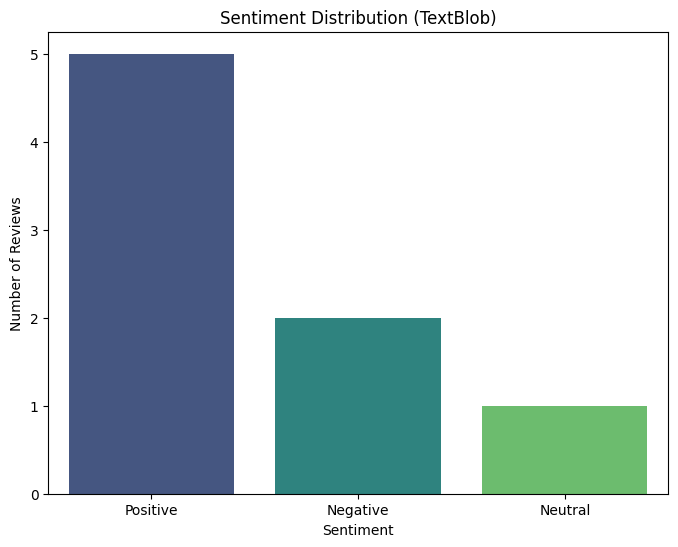

TextBlob Sentiment Value Counts:
textblob_sentiment
Positive    5
Negative    2
Neutral     1
Name: count, dtype: int64


In [ ]:
# Visualize TextBlob Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='textblob_sentiment', data=df, hue='textblob_sentiment', palette='viridis', legend=False)
plt.title('Sentiment Distribution (TextBlob)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

print("TextBlob Sentiment Value Counts:")
print(df['textblob_sentiment'].value_counts())

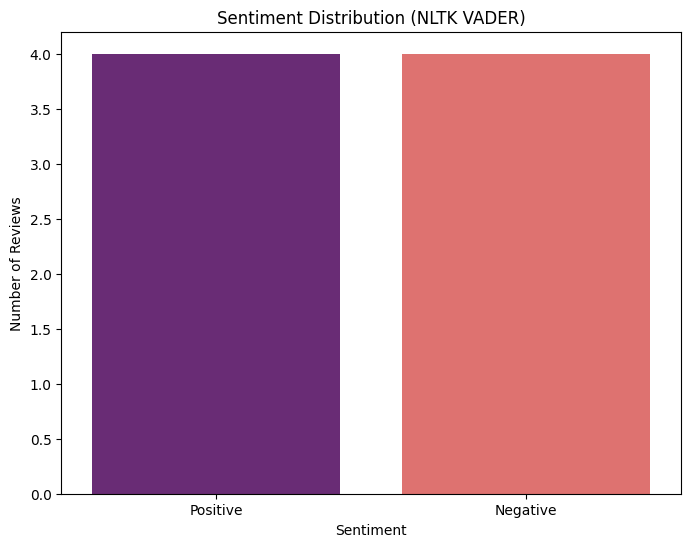

NLTK VADER Sentiment Value Counts:
vader_sentiment
Positive    4
Negative    4
Name: count, dtype: int64


In [ ]:
# Visualize NLTK VADER Sentiment Distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='vader_sentiment', data=df, hue='vader_sentiment', palette='magma', legend=False)
plt.title('Sentiment Distribution (NLTK VADER)')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

print("NLTK VADER Sentiment Value Counts:")
print(df['vader_sentiment'].value_counts())